In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

In [2]:
file_name = "../dataset/ecommerce_cleaned.csv"
df = pd.read_csv(file_name)

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,...,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,order_month,order_year,order_day_of_week,age_group
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,...,0,139.47,7.88,31.17,60,1,12,2023,5,Middle
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,...,0,24.73,4.60,-2.62,37,0,4,2025,3,Adult
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,...,0,166.80,6.58,13.44,34,0,10,2024,1,Adult
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,...,0,63.67,5.50,2.14,21,1,9,2024,5,Young
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,...,0,13.88,2.74,1.15,39,0,12,2024,5,Adult


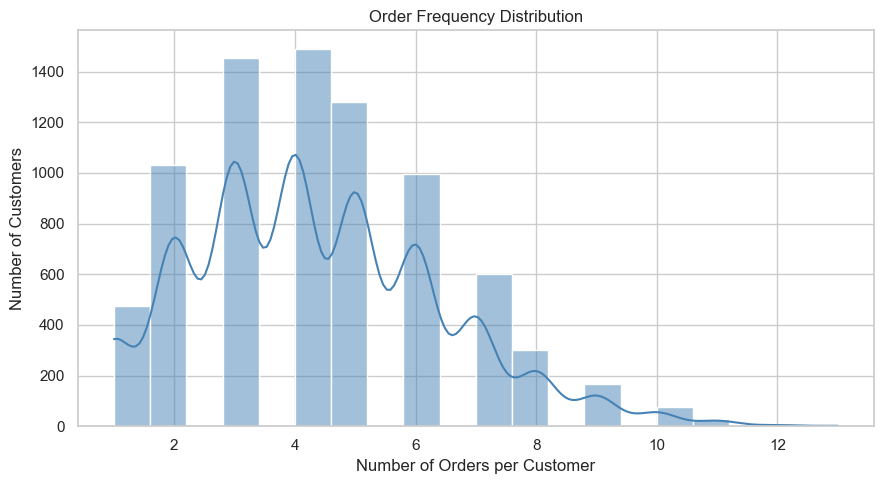

In [3]:
## Analyze order frequency per customer


order_freq = df.groupby("customer_id")["order_id"].count().reset_index()
order_freq.columns = ["customer_id", "order_count"]

plt.figure(figsize=(9, 5))
sns.histplot(order_freq["order_count"], bins=20, kde=True, color="steelblue")
plt.title("Order Frequency Distribution")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [4]:
print(order_freq["order_count"].describe())

count    7903.000000
mean        4.365431
std         2.048718
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        13.000000
Name: order_count, dtype: float64


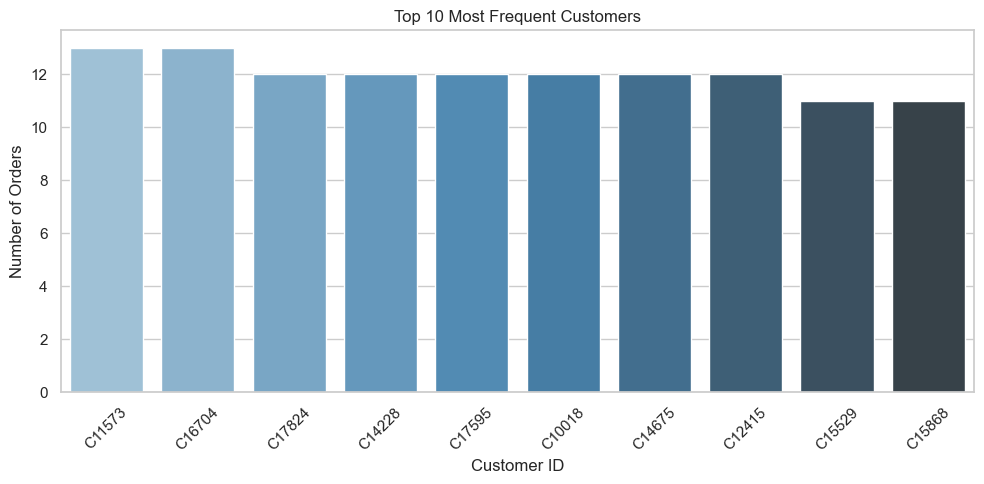

In [5]:
## top most frequent customers

top_freq = order_freq.sort_values("order_count", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_freq, x="customer_id", y="order_count", palette="Blues_d")
plt.title("Top 10 Most Frequent Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

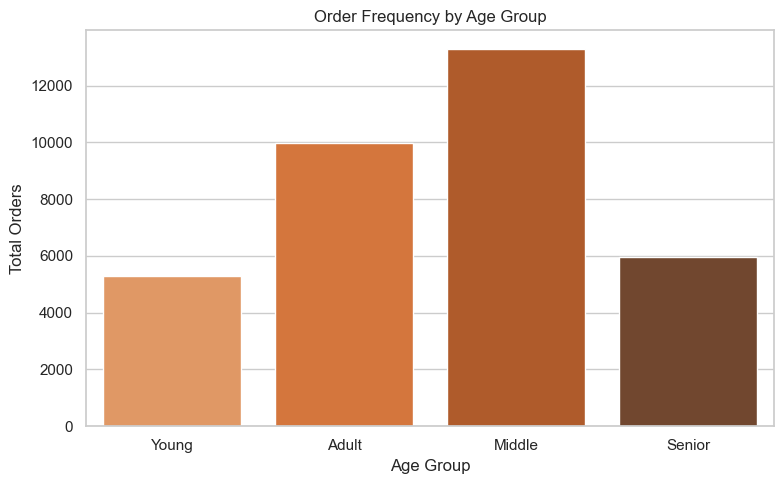

In [6]:
age_freq = df.groupby("age_group", observed=True)["order_id"].count().reset_index()
age_freq.columns = ["age_group", "order_count"]

plt.figure(figsize=(8, 5))
sns.barplot(data=age_freq, x="age_group", y="order_count",
            order=["Young", "Adult", "Middle", "Senior"], palette="Oranges_d")
plt.title("Order Frequency by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()